
**Предметная область:** бизнес / маркетинг   


### Идея проекта
Цель проекта — построить и исследовать модель машинного обучения, которая по характеристикам пользовательской сессии на сайте интернет-магазина предсказывает, завершится ли сессия покупкой.

### Практическая значимость
Такая модель может использоваться для:
- персонализации интерфейса сайта;
- более точного таргетинга рекламы и акций;
- выделения сессий с высокой вероятностью покупки.

## 1. Постановка задачи:


### Бизнес-задача
Интернет-магазину важно понимать, какие пользовательские сессии с высокой вероятностью завершатся покупкой. Это позволяет вовремя предлагать скидки, рекомендации .

### ML-задача
Необходимо по признакам одной сессии предсказать целевую переменную **Revenue**:  
True — пользователь совершил покупку;  
False — пользователь не совершил покупку.  

Следовательно, это **задача бинарной классификации**.

### Основные гипотезы
1. Чем дольше пользователь изучает товарные страницы, тем выше вероятность покупки.
2. Возвращающиеся посетители чаще совершают покупку, чем новые.
3. Чем выше ExitRates, тем ниже вероятность покупки.
4. Месяц сессии связан с вероятностью покупки.

## 2. Данные:


### Описание данных

Датасет **Online Shoppers Purchasing Intention Dataset** из UCI Machine Learning Repository.

### Краткое описание
Каждая строка датасета — это отдельная сессия пользователя на сайте интернет-магазина.  


Признаки:  
**Administrative** — количество административных страниц, которые пользователь посетил за сессию. Это могут быть страницы входа, регистрации, профиля, корзины, оформления заказа и другие служебные разделы сайта.  
**Administrative_Duration** — общее время, которое пользователь провёл на административных страницах за сессию.  
**Informational** — количество информационных страниц, просмотренных за сессию. Обычно это страницы с описанием условий доставки, возврата, справочной информацией, FAQ и т.п.    
**Informational_Duration** — суммарное время, проведённое пользователем на информационных страницах.  
**ProductRelated** — количество страниц, связанных с товарами, которые пользователь посетил за сессию.   
**ProductRelated_Duration** — общее время, проведённое на страницах товаров.   
**BounceRates** — показатель отказов. Он отражает долю пользователей, которые вошли на сайт через данную страницу и ушли, не совершив больше никаких значимых действий в рамках сессии.  
**ExitRates** — показатель выхода. Он показывает, как часто конкретная страница оказывается последней в сессии пользователя.     
**PageValues** — средняя ценность страницы перед завершением транзакции. Этот признак показывает, насколько просмотр определённой страницы связан с будущей покупкой.  
**SpecialDay** — степень близости даты сессии к какому-либо специальному дню или празднику, например ко Дню матери или Дню святого Валентина, когда вероятность покупки может меняться. Чем выше значение, тем ближе дата визита к такому событию.  
**Month** — месяц, в который произошла сессия. Этот признак помогает учитывать сезонность пользовательского поведения.  
**OperatingSystems** — код операционной системы пользователя. Это технический признак, который описывает среду, из которой пользователь зашёл на сайт.  
**Browser** — код браузера пользователя.    
**Region** — код региона, из которого пришёл пользователь. Позволяет учитывать географические различия в поведении покупателей.  
**TrafficType** — код типа источника трафика. Этот признак показывает, откуда пользователь попал на сайт: например, из поиска, рекламы, прямого захода.   
**VisitorType** — тип посетителя. Показывает, является ли пользователь новым, возвращающимся или относится к другой категории. Это важный признак, потому что новые и постоянные посетители часто ведут себя по-разному.    
**Weekend** — признак того, была ли сессия совершена в выходной день.   
**Revenue** — целевая переменная. Показывает, завершилась ли сессия покупкой: True — покупка была, False — покупки не было. 

In [34]:
!pip install ucimlrepo -q

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import ( precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

import joblib

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42

### Загрузка данных
Сайт откуда скачан датасет: https://archive-beta.ics.uci.edu/dataset/468/online%2Bshoppers%2Bpurchasing%2Bintention%2Bdataset/files


In [5]:
DATA_PATH = Path("online_shoppers_intention.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("Файл online_shoppers_intention.csv не найден")

df = pd.read_csv(DATA_PATH)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Первичный осмотр данных

In [6]:
print('Размер датасета:', df.shape)
print('\nТипы данных:')
print()
display(df.dtypes)

print('\nКоличество пропусков по столбцам:')
print()
display(df.isna().sum().sort_values(ascending=False))

print('\nКоличество полных дубликатов:', df.duplicated().sum())

Размер датасета: (12330, 18)

Типы данных:



Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


Количество пропусков по столбцам:



Administrative             0
Administrative_Duration    0
Weekend                    0
VisitorType                0
TrafficType                0
Region                     0
Browser                    0
OperatingSystems           0
Month                      0
SpecialDay                 0
PageValues                 0
ExitRates                  0
BounceRates                0
ProductRelated_Duration    0
ProductRelated             0
Informational_Duration     0
Informational              0
Revenue                    0
dtype: int64


Количество полных дубликатов: 125


**Пропусков в данных нет, поэтому этап заполнения можно пропустить.  
Однако найдено 125 полных дубликатов, поэтому перед обучением моделей их следует удалить, чтобы они не испортили результаты анализа.**

In [7]:
df.sample(5, random_state=RANDOM_STATE)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,Nov,1,8,6,11,Returning_Visitor,False,False
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,Mar,2,2,3,2,Returning_Visitor,False,True
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,Nov,2,2,2,2,Returning_Visitor,False,False
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,Aug,2,5,7,4,Returning_Visitor,False,False
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,Aug,2,2,3,1,Returning_Visitor,True,False


## 3. Предобработка:


### Подготовка типов данных и очистка

 Приведение целевой переменной к целочисленному формату

In [8]:
df = df.copy()
df['Revenue'] = df['Revenue'].astype(int)


Некоторые признаки переводим в строку потому, что это категория, а не величина.

In [9]:
if 'Weekend' in df.columns:
    df['Weekend'] = df['Weekend'].astype(str)

if 'VisitorType' in df.columns:
    df['VisitorType'] = df['VisitorType'].astype(str)

# Эти признаки являются категориальными кодами
for col in ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month']:
    if col in df.columns:
        df[col] = df[col].astype(str)

 Удалим дубликаты

In [10]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f'Удалено дубликатов: {before - after}')
print('Новый размер датасета:', df.shape)

Удалено дубликатов: 125
Новый размер датасета: (12205, 18)


### Feature engineering

Добавим несколько новых признаков:  
  
TotalPages — общее число просмотренных страниц  
TotalDuration — общее время сессии на основных типах страниц  
AvgTimePerPage — среднее время на одну страницу  
ProductShare — доля товарных страниц среди всех просмотренных  
BounceExitGap — разница между ExitRates и BounceRates  (насколько пользователи просто уходят с этой страницы после долгого просмотра сайта, а не сразу после входа)  
IsReturningVisitor — бинарный признак возвратного посетителя  (1- пользователь уже был на сайте раньше)  

In [11]:
df = df.copy()

df['TotalPages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

df['TotalDuration'] = ( df['Administrative_Duration'] + df['Informational_Duration']
                                                    + df['ProductRelated_Duration'])

df['AvgTimePerPage'] = np.where( df['TotalPages'] > 0,  df['TotalDuration'] / df['TotalPages'], 0)

df['ProductShare'] = np.where( df['TotalPages'] > 0, df['ProductRelated'] / df['TotalPages'],0)

df['BounceExitGap'] = df['ExitRates'] - df['BounceRates']

df['IsReturningVisitor'] = (df['VisitorType'] == 'Returning_Visitor').astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,TotalPages,TotalDuration,AvgTimePerPage,ProductShare,BounceExitGap,IsReturningVisitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0,1,0.000000,0.000000,1.0,0.00,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0,2,64.000000,32.000000,1.0,0.10,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0,1,0.000000,0.000000,1.0,0.00,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0,2,2.666667,1.333333,1.0,0.09,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0,10,627.500000,62.750000,1.0,0.03,1


 ### EDA

#### Баланс классов:

In [12]:
target_share = df['Revenue'].value_counts(normalize=True).sort_index()
print('Доли классов:')
print()
display(target_share.rename(index={0: 'Нет покупки', 1: 'Покупка'}))

Доли классов:



Revenue
Нет покупки    0.843671
Покупка        0.156329
Name: proportion, dtype: float64

target_share = какая доля сессий без покупки (0), с покупкой (1)

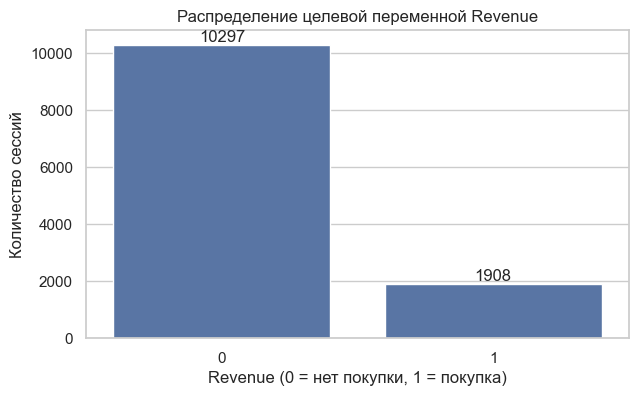

In [13]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Revenue')
plt.title('Распределение целевой переменной Revenue')
plt.xlabel('Revenue (0 = нет покупки, 1 = покупка)')
plt.ylabel('Количество сессий')

#добавляем подписи на столбцы(ax.containers - набор всех столбцов на графике)
for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Вывод:**    
Распределение целевой переменной Revenue является несбалансированным:   
сессий без покупки значительно больше, чем сессий с покупкой.

### Распределение времени на товарных страницах

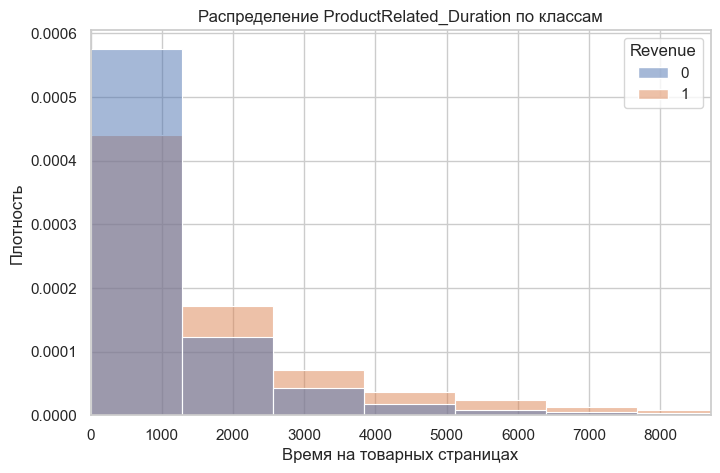

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot( data=df, x='ProductRelated_Duration', hue='Revenue', bins=50,
    stat='density', common_norm=False)
plt.xlim(0, df['ProductRelated_Duration'].quantile(0.99))
plt.title('Распределение ProductRelated_Duration по классам')
plt.xlabel('Время на товарных страницах')
plt.ylabel('Плотность')
plt.show()

**Вывод:**   
Плотность нам показывает "Насколько типичны такие значения внутри этого класса"  

С помощью плотности делаем сравнение в нормализованном виде: мы смотрим не на абсолютное число объектов в классах, а на то, в каких диапазонах значений чаще сосредоточены наблюдения каждого класса.  

Пользователи, совершившие покупку, в среднем проводят на товарных страницах больше времени, чем пользователи без покупки.   
Однако классы сильно пересекаются, поэтому одного этого признака недостаточно для точного предсказания покупки.  

### PageValues в группах с покупкой и без покупки

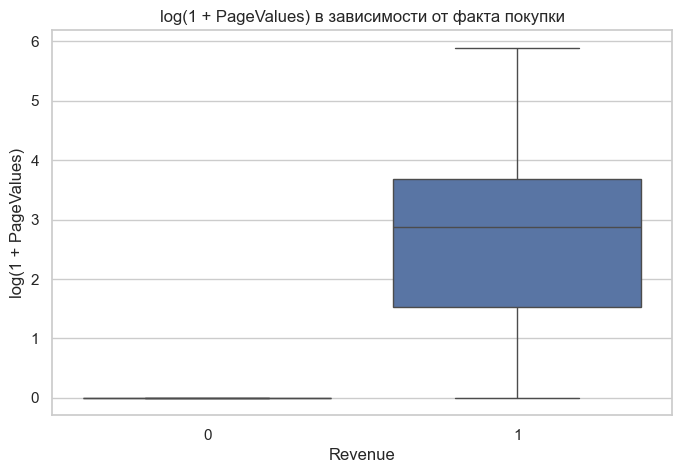

In [15]:
df['LogPageValues'] = np.log1p(df['PageValues'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Revenue', y='LogPageValues', showfliers=False)
plt.title('log(1 + PageValues) в зависимости от факта покупки')
plt.xlabel('Revenue')
plt.ylabel('log(1 + PageValues)')
plt.show()

**Вывод:**  
Сделали логарифмическое преобразования признака PageValues(чтобы не мешали выбросы).  
Для сессий без покупки (0) значения PageValues почти полностью сосредоточены около нуля,  
тогда как для сессий с покупкой (Revenue = 1) распределение значительно смещено вверх и имеет   заметный разброс.   
Это говорит о том, что признак PageValues для нас очень информативный и очень связан с фактом   совершения покупки.

### Доля покупок в зависимости от типа посетителя

Revenue,0,1
VisitorType,,
New_Visitor,0.750738,0.249262
Other,0.802469,0.197531
Returning_Visitor,0.859074,0.140926


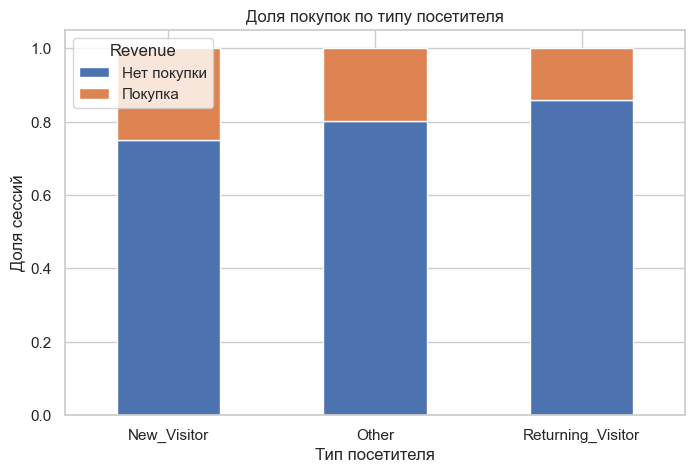

In [16]:
visitor_rev = pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index')
display(visitor_rev)

ax = visitor_rev.rename(columns={0: 'Нет покупки', 1: 'Покупка'}).plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)
plt.title('Доля покупок по типу посетителя')
plt.xlabel('Тип посетителя')
plt.ylabel('Доля сессий')
plt.legend(title='Revenue')
plt.xticks(rotation=0)
plt.show()

**Вывод:**  
График показывает долю сессий с покупкой и без покупки внутри каждого типа посетителя. Из графика видно, что наибольшая доля покупок наблюдается у New_Visitor, а наименьшая — у Returning_Visitor.

### Доля покупок по месяцам

,Month,PurchaseRate
2,Feb,0.016575
5,Mar,0.103226
6,May,0.109643
4,June,0.101754
3,Jul,0.152778
0,Aug,0.175520
9,Sep,0.191964
8,Oct,0.209472
7,Nov,0.254863
1,Dec,0.126612


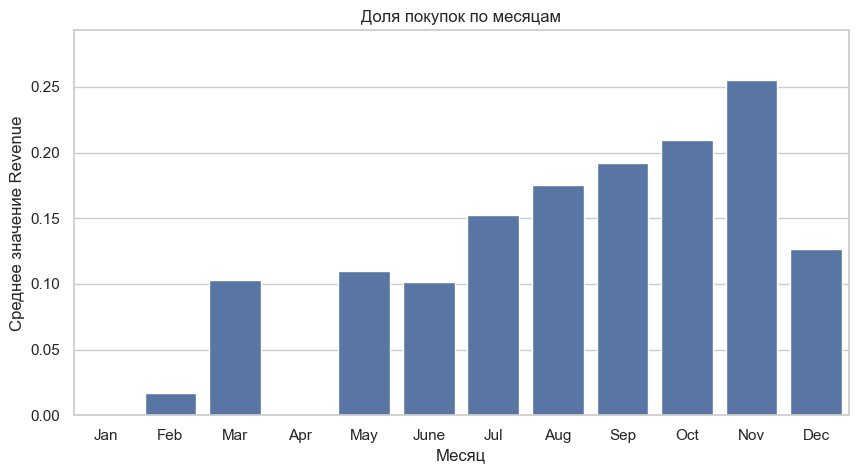

In [17]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_rate = df.groupby('Month')['Revenue'].mean().reset_index(name='PurchaseRate')
month_rate['Month'] = pd.Categorical(month_rate['Month'], categories=month_order, ordered=True)
month_rate = month_rate.sort_values('Month')

display(month_rate)

plt.figure(figsize=(10, 5))
sns.barplot(data=month_rate, x='Month', y='PurchaseRate')
plt.title('Доля покупок по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Среднее значение Revenue')
plt.ylim(0, month_rate['PurchaseRate'].max() * 1.15)
plt.show()

**Вывод:**  
Анализ доли покупок по месяцам показывает наличие сезонности. Наиболее высокая доля покупок наблюдается в осенние месяцы, особенно в ноябре. Начиная с июля доля покупок постепенно растёт, а в декабре снова снижается. Месяц посещения сайта действительно влияет на вероятность покупки и может быть информативным признаком для модели.

### Корреляционный анализ числовых признаков

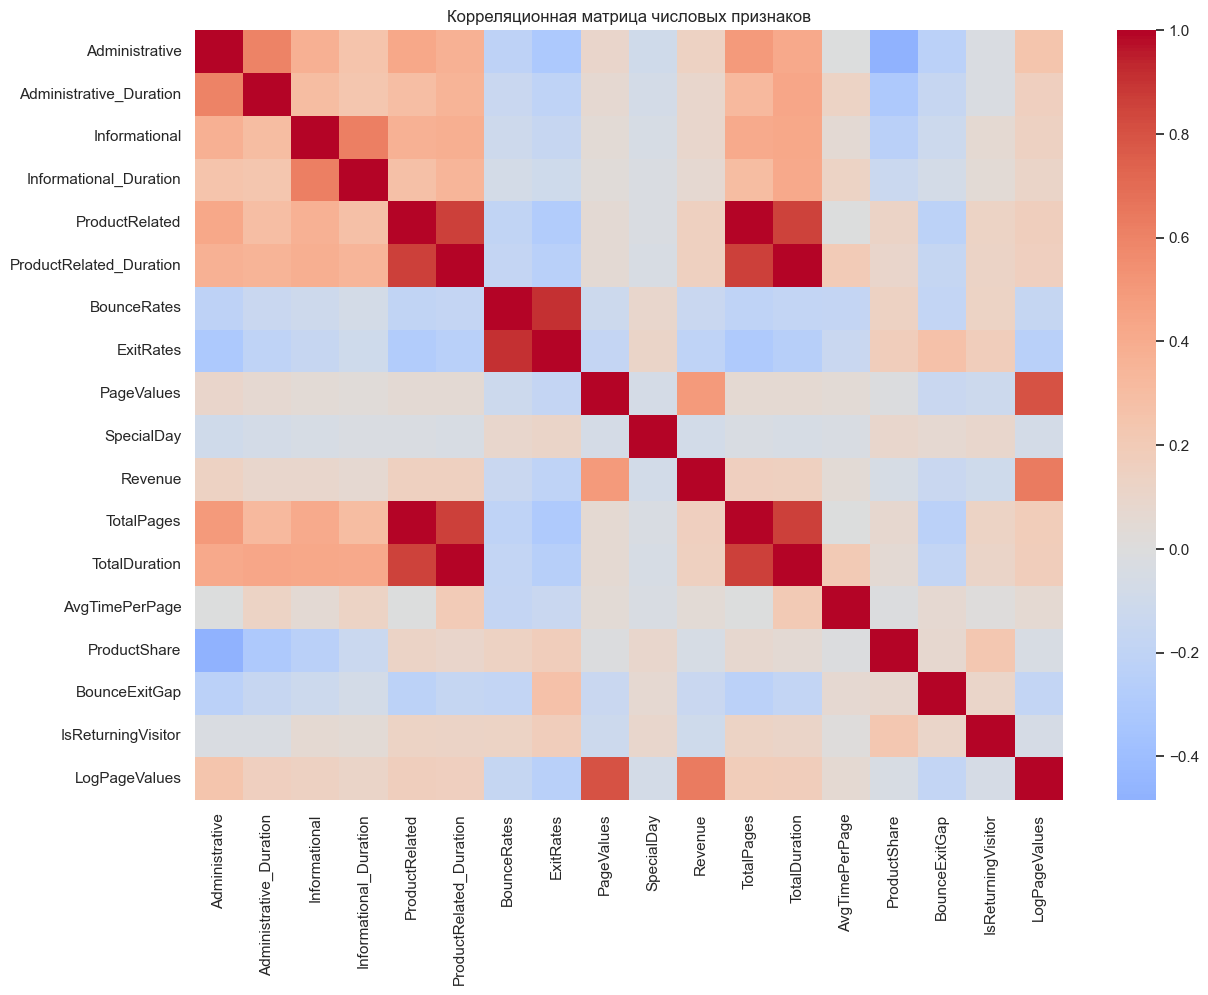

Корреляции числовых признаков с Revenue:


Revenue                    1.000000
LogPageValues              0.634293
PageValues                 0.491894
TotalPages                 0.161535
ProductRelated             0.156042
TotalDuration              0.153720
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
AvgTimePerPage             0.038116
ProductShare              -0.044197
SpecialDay                -0.083601
IsReturningVisitor        -0.102847
BounceExitGap             -0.141586
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64

In [19]:
numeric_for_corr = df.select_dtypes(include=np.number).copy()

corr = numeric_for_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

corr_with_target = corr['Revenue'].sort_values(ascending=False)
print('Корреляции числовых признаков с Revenue:')
display(corr_with_target)

**Вывод:**
Наиболее сильную положительную связь с целевой переменной Revenue имеют признаки PageValues и LogPageValues. Также положительно с фактом покупки связаны признаки, характеризующие активность пользователя на сайте: TotalPages, ProductRelated, TotalDuration и ProductRelated_Duration. Отрицательная корреляция наблюдается у ExitRates и BounceRates, чем выше вероятность выхода или отказа, тем ниже вероятность покупки. 

## 4. Подготовка данных к моделированию:

In [20]:
model_df = df.copy()

# LogPageValues использовался только для EDA, чтобы график был читаемым
# Для моделирования оставим исходный PageValues
if 'LogPageValues' in model_df.columns:
    model_df = model_df.drop(columns=['LogPageValues'])

X = model_df.drop(columns=['Revenue'])
y = model_df['Revenue']

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print('\nРаспределение целевой переменной:')
display(y.value_counts(normalize=True).rename({0: 'Нет покупки', 1: 'Покупка'}))

Размер X: (12205, 23)
Размер y: (12205,)

Распределение целевой переменной:


Revenue
Нет покупки    0.843671
Покупка        0.156329
Name: proportion, dtype: float64

In [21]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print('Категориальные признаки:')
print(categorical_features)

print('\nЧисловые признаки:')
print(numeric_features)

Категориальные признаки:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Числовые признаки:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'TotalPages', 'TotalDuration', 'AvgTimePerPage', 'ProductShare', 'BounceExitGap', 'IsReturningVisitor']


### Разделяем данные на train и test:

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

print('\nРаспределение классов в y_train:')
display(
    pd.DataFrame({
        'count': y_train.value_counts().sort_index(),
        'share': y_train.value_counts(normalize=True).sort_index()
    }).rename(index={0: 'Нет покупки', 1: 'Покупка'})
)

print('\nРаспределение классов в y_test:')
display(
    pd.DataFrame({
        'count': y_test.value_counts().sort_index(),
        'share': y_test.value_counts(normalize=True).sort_index()
    }).rename(index={0: 'Нет покупки', 1: 'Покупка'})
)

Размер обучающей выборки: (9764, 23)
Размер тестовой выборки: (2441, 23)

Распределение классов в y_train:


,count,share
Revenue,,
Нет покупки,8238,0.843712
Покупка,1526,0.156288



Распределение классов в y_test:


,count,share
Revenue,,
Нет покупки,2059,0.843507
Покупка,382,0.156493


### Нормализация и заполение пропусков:

In [23]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', ohe)])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay', 'TotalPages', 'TotalDuration',
                                  'AvgTimePerPage', 'ProductShare',
                                  'BounceExitGap', 'IsReturningVisitor']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Month', 'OperatingSystems', 'Browser',
                                  'Region', 'TrafficType', 'VisitorType',
                                  'Weekend'])])

## 5. Моделирование:


### Обучение и сравнение моделей

Для решения задачи классификации были выбраны следующие модели:

1. Baseline:  
- **Logistic Regression**

2. Классические модели:    
- **KNeighborsClassifier** 
- **DecisionTreeClassifier** 
- **SVC**

3. Ансамбли:
- **RandomForestClassifier** 
- **GradientBoostingClassifier**

4. Модель грубокого обучения:
- **MLPClassifier**

In [29]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=15),
    'SVC': SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
    'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE),
    'MLPClassifier': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE)}

In [30]:
results = []
fitted_models = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    fitted_models[model_name] = pipe
    
    y_pred = pipe.predict(X_test)
    
    if hasattr(pipe, 'predict_proba'):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)
    
    results.append({
        'model': model_name,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results).sort_values(['roc_auc', 'f1'], ascending=False).reset_index(drop=True)
display(results_df)

,model,precision,recall,f1,roc_auc
0,GradientBoostingClassifier,0.708824,0.630890,0.667590,0.936367
1,RandomForestClassifier,0.807175,0.471204,0.595041,0.925562
2,MLPClassifier,0.665689,0.594241,0.627939,0.917961
3,LogisticRegression,0.764423,0.416230,0.538983,0.901007
4,DecisionTreeClassifier,0.702454,0.599476,0.646893,0.900454
5,SVC,0.741036,0.486911,0.587678,0.871771
6,KNeighborsClassifier,0.728916,0.316754,0.441606,0.837943


**Вывод:**  
По результатам сравнения моделей наилучшее качество показал **GradientBoostingClassifier**: он имеет максимальное значение ROC-AUC = 0.936 и одновременно лучший F1-score = 0.668. Значит модель лучше остальных справляется с общей задачей разделения классов и при этом обеспечивает наиболее удачный баланс между precision и recall.

Таким образом, для дальнейшего анализа, подбора гиперпараметров и интерпретации выбраем **GradientBoostingClassifier**.

## 6. Подбор гиперпараметров:

Для настройки лучшей модели используем библиотеку **Optuna**

In [32]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])}
    
    model = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='gradient_boosting_optuna')
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-04-23 10:06:34,609] A new study created in memory with name: gradient_boosting_optuna


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-23 10:06:46,016] Trial 0 finished with value: 0.9261180776295476 and parameters: {'n_estimators': 200, 'learning_rate': 0.13899392610084563, 'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 3, 'subsample': 0.8737609215121032, 'max_features': None}. Best is trial 0 with value: 0.9261180776295476.
[I 2026-04-23 10:06:58,551] Trial 1 finished with value: 0.9244015050266724 and parameters: {'n_estimators': 300, 'learning_rate': 0.01436645277575977, 'max_depth': 2, 'min_samples_split': 12, 'min_samples_leaf': 1, 'subsample': 0.7926320643237086, 'max_features': None}. Best is trial 0 with value: 0.9261180776295476.
[I 2026-04-23 10:07:06,954] Trial 2 finished with value: 0.9306804323931003 and parameters: {'n_estimators': 100, 'learning_rate': 0.07863900138764515, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 8, 'subsample': 0.923652321180454, 'max_features': None}. Best is trial 2 with value: 0.9306804323931003.
[I 2026-04-23 10:07:11,852] Trial 3 finish

In [33]:
print('Лучшее значение ROC-AUC на кросс-валидации:')
print(study.best_value)

print('\nЛучшие параметры:')
print(study.best_params)

Лучшее значение ROC-AUC на кросс-валидации:
0.9322476882546841

Лучшие параметры:
{'n_estimators': 350, 'learning_rate': 0.014051965417250744, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 9, 'subsample': 0.8588516446052751, 'max_features': None}


**Вывод:**  
Полученные значения показывают, что для данной задачи более эффективной оказалась модель с достаточно большим числом деревьев и небольшой скоростью обучения, то есть бустинг обучается более постепенно и аккуратно. Увеличенная глубина деревьев (max_depth = 5) позволяет учитывать более сложные зависимости между признаками, а параметры min_samples_split и min_samples_leaf дополнительно ограничивают переобучение. Использование subsample < 1 также делает модель более устойчивой и снижает риск подгонки под обучающую выборку.

**Далее обучим итоговую модель с найденными параметрами на обучающей выборке и сравним её качество на тестовой выборке с базовой версией GradientBoostingClassifier**

In [35]:
best_gb_params = study.best_params

tuned_best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier( random_state=RANDOM_STATE, **best_gb_params))])

tuned_best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'TotalPa...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Month', 'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType', 'VisitorType',
                                                   'Weekend'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.014051965417250744,
                                            max_depth=5, min_samples_leaf=9,
                                            min_samples_split=11,
                                            n_estimators=350, random_state=42,
                                            subsample=0.8588516446052751))])

In [38]:
tuned_pred = tuned_best_model.predict(X_test)
tuned_score = tuned_best_model.predict_proba(X_test)[:, 1]

tuned_metrics = pd.DataFrame([{
    'model': 'Tuned GradientBoostingClassifier (Optuna)',
    'precision': precision_score(y_test, tuned_pred),
    'recall': recall_score(y_test, tuned_pred),
    'f1': f1_score(y_test, tuned_pred),
    'roc_auc': roc_auc_score(y_test, tuned_score)}])



In [39]:
base_gb_metrics = results_df[results_df['model'] == 'GradientBoostingClassifier'].copy()
comparison_df = pd.concat([base_gb_metrics, tuned_metrics], ignore_index=True)

display(comparison_df)

,model,precision,recall,f1,roc_auc
0,GradientBoostingClassifier,0.708824,0.630890,0.667590,0.936367
1,Tuned GradientBoostingClassifier (Optuna),0.714715,0.623037,0.665734,0.937062


**Вывод:**  
Подбор гиперпараметров через Optuna дал очень небольшое улучшение ROC-AUC, но не улучшил F1-score. Поэтому итог можно считать частично положительным: модель стала немного лучше по качеству ранжирования, но заметного практического выигрыша не получила.

In [40]:
print('Classification report для настроенной модели:')
print(classification_report(y_test, tuned_pred))

Classification report для настроенной модели:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.71      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



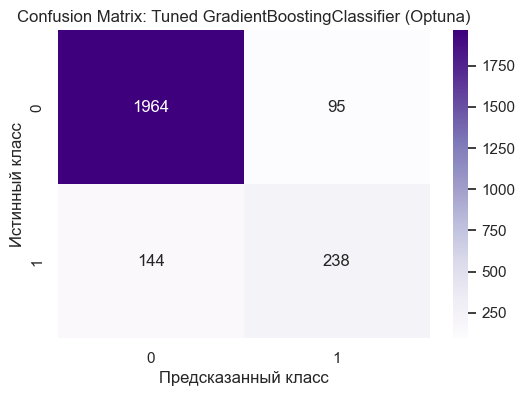

In [43]:
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Tuned GradientBoostingClassifier (Optuna)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

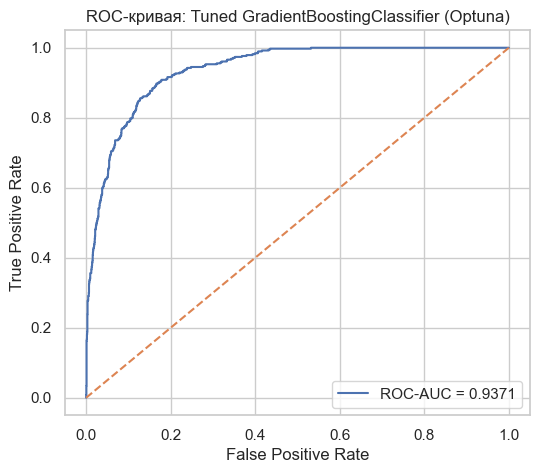

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, tuned_score)
auc_value = roc_auc_score(y_test, tuned_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc_value:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC-кривая: Tuned GradientBoostingClassifier (Optuna)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 7. Интерпретация модели

### Feature importance

In [45]:
perm_result = permutation_importance( tuned_best_model, X_test, y_test, n_repeats=10,random_state=RANDOM_STATE,scoring='roc_auc')

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std}).sort_values('importance_mean', ascending=False)

display(importance_df.head(15))

,feature,importance_mean,importance_std
8,PageValues,0.324042,0.008701
10,Month,0.050211,0.005236
20,ProductShare,0.004859,0.001074
7,ExitRates,0.001943,0.000739
6,BounceRates,0.001712,0.000767
14,TrafficType,0.001409,0.000743
19,AvgTimePerPage,0.001125,0.000723
17,TotalPages,0.001120,0.000422
21,BounceExitGap,0.000906,0.000463
5,ProductRelated_Duration,0.000877,0.000628


**Вывод:**  
Созданные на этапе feature engineering признаки оказали большое влияние на модель.
Наиболее значимым среди них стал признак ProductShare, также признаки AvgTimePerPage, TotalPages, BounceExitGap и TotalDuration.

### Объяснение решений модели через Partial Dependence

In [57]:
top1_feature = importance_df.head(1)['feature'].tolist()

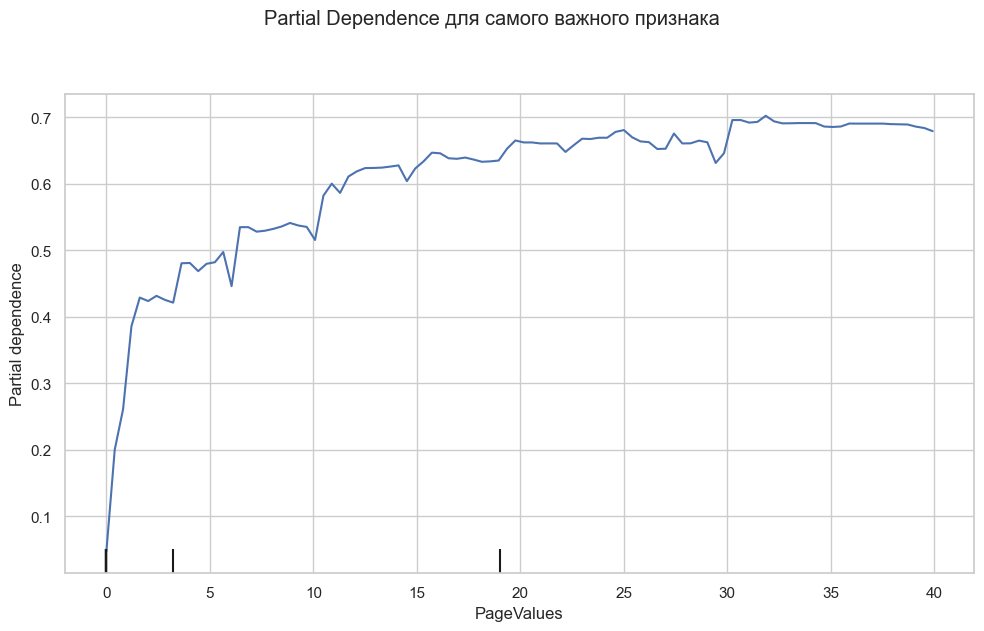

In [60]:
fig, ax = plt.subplots(1, len(top1_feature), figsize=(10, 6))

PartialDependenceDisplay.from_estimator( tuned_best_model, X_test, features=top1_feature, kind='average', ax=ax)

plt.suptitle('Partial Dependence для самого важного признака', y=1.05)
plt.tight_layout()
plt.show()

## 8. Проверка гипотез

1. Чем дольше пользователь изучает товарные страницы, тем выше вероятность покупки.  
**Подтверждается:** По результатам анализа видно, что у пользователей, совершивших покупку, время на товарных страницах в среднем выше. Это также подтверждает важность признака ProductRelated_Duration: более длительное изучение товаров связано с большей вероятностью покупки.  
2. Возвращающиеся посетители чаще совершают покупку, чем новые.  
**Не подтверждается:**  Получилось наоборот: доля покупок у New_Visitor оказалась выше, чем у Returning_Visitor. Значит, связь между типом посетителя и фактом покупки есть, но её направление не совпало с исходным предположением.  
3. Чем выше ExitRates, тем ниже вероятность покупки.  
**Подтверждается:** Это подтверждается корреляционным анализом и интерпретацией модели. Чем выше показатель выхода, тем ниже вероятность того, что сессия закончится покупкой.  
4. Месяц сессии связан с вероятностью покупки.  
**Подтверждается:** По распределению покупок по месяцам видно, что доля покупок заметно различается в разные периоды.

## 9. Выводы и сохранение модели

In [63]:
joblib.dump(tuned_best_model, 'best_model.pkl')
print('Модель успешно сохранена в файл best_model.pkl')

Модель успешно сохранена в файл best_model.pkl


### Итоговый вывод:

В ходе работы была решена задача классификации: предсказание факта покупки по характеристикам пользовательской сессии интернет-магазина. Были выполнены предобработка данных, исследовательский анализ, построение и сравнение нескольких моделей машинного обучения, а также подбор гиперпараметров для лучшей модели.  

По результатам экспериментов наилучшее качество показал GradientBoostingClassifier. Интерпретация модели показала, что наибольшее влияние на вероятность покупки оказывают признаки PageValues, ExitRates, активность на товарных страницах и месяц сессии. Проверка гипотез подтвердила, что длительность просмотра товаров, показатель выхода и сезонность связаны с вероятностью покупки, тогда как гипотеза о более высокой конверсии у возвращающихся посетителей не подтвердилась.  

Таким образом, цель проекта была достигнута: был реализован полный цикл ML-решения от первоначального исследования данных до сохранения итоговой модели.  